# 1) Nettoyage et prétraitement des données.

## 1.1 Importation des librairies

In [1]:
# Importation des librairies de base
import pandas as pd
import numpy as np

# Importation des modules Scikit-Learn pour le prétraitement
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Désactiver les avertissements inutiles
import warnings
warnings.filterwarnings('ignore')

## 1.2 Chargement, Traduction et Nettoyage

In [4]:
# Chargement du dataset principal
donnees_vols = pd.read_csv('PrixDuVol_Dataset_bruite.csv')

print(f"Dimensions initiales : {donnees_vols.shape}")

# 1. Suppression de la colonne d'index parasite si elle existe
if donnees_vols.columns[0] == 'Unnamed: 0':
    donnees_vols = donnees_vols.drop(columns=['Unnamed: 0'])

# 2. Traduction des colonnes en français pour plus de clarté
dictionnaire_traduction = {
    'airline': 'compagnie_aerienne',
    'flight': 'vol',
    'source_city': 'ville_depart',
    'departure_time': 'moment_depart',
    'stops': 'escales',
    'arrival_time': 'moment_arrivee',
    'destination_city': 'ville_destination',
    'class': 'classe',
    'duration': 'duree',
    'days_left': 'jours_avant_depart',
    'price': 'prix'
}
donnees_vols = donnees_vols.rename(columns=dictionnaire_traduction)

# 3. Traitement du bruit : conversion des 'NA' de la colonne 'duree' en NaN (valeurs nulles reconnues)
donnees_vols['duree'] = pd.to_numeric(donnees_vols['duree'], errors='coerce')

# 4. Suppression des doublons
nombre_doublons = donnees_vols.duplicated().sum()
donnees_vols = donnees_vols.drop_duplicates()
print(f"Nombre de doublons supprimés : {nombre_doublons}")
print(f"Dimensions après nettoyage : {donnees_vols.shape}")

# 5. Séparation de la cible (Y) et des caractéristiques (X)
# On exclut 'vol' car cet identifiant unique n'aide pas le modèle
X = donnees_vols.drop(columns=['prix', 'vol'])
y = donnees_vols['prix']

Dimensions initiales : (300153, 12)
Nombre de doublons supprimés : 0
Dimensions après nettoyage : (300153, 11)


## 1.3 Création du Pipeline de Prétraitement

In [5]:
# --- Définition des groupes de variables ---

# Variables numériques (nécessitent une imputation et une normalisation)
colonnes_numeriques = ['duree', 'jours_avant_depart']

# Variables ordinales (l'ordre logique compte)
colonnes_ordinales = ['escales', 'classe']
ordre_escales = ['zero', 'one', 'two_or_more'] # On garde les valeurs anglaises d'origine contenues dans les cellules
ordre_classe = ['Economy', 'Business']

# Variables nominales (pas de hiérarchie)
colonnes_nominales = ['compagnie_aerienne', 'ville_depart', 'moment_depart', 'moment_arrivee', 'ville_destination']

# --- Création des sous-pipelines ---

# Transformateur pour les nombres : remplace les vides par la médiane, puis centre et réduit
transformateur_numerique = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='median')),
    ('normalisation', StandardScaler())
])

# Transformateur pour les données ordinales : remplace les vides par le plus fréquent, puis encode selon l'ordre
transformateur_ordinal = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OrdinalEncoder(categories=[ordre_escales, ordre_classe]))
])

# Transformateur pour les données nominales : remplace les vides par le plus fréquent, puis encode en binaire (One-Hot)
transformateur_nominal = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# --- Assemblage final ---

preprocesseur = ColumnTransformer(
    transformers=[
        ('num', transformateur_numerique, colonnes_numeriques),
        ('ord', transformateur_ordinal, colonnes_ordinales),
        ('nom', transformateur_nominal, colonnes_nominales)
    ])

# Test du pipeline sur nos données X
X_prepare = preprocesseur.fit_transform(X)

print(f"Dimensions de X après le passage dans le pipeline : {X_prepare.shape}")

Dimensions de X après le passage dans le pipeline : (300153, 29)


# 2) Analyse exploratoire des données (EDA')

## 2.1 Statistiques Descriptives Globales

In [ ]:
# --- 1. Vue d'ensemble des données ---
print("--- Informations générales ---")
donnees_vols.info()

print("\n--- Statistiques des variables numériques ---")
# describe() donne la moyenne, l'écart-type, les min/max et les quartiles
display(donnees_vols.describe().round(2))

print("\n--- Statistiques des variables catégorielles ---")
# include='O' (pour Object) cible les chaînes de caractères
display(donnees_vols.describe(include='O'))

## 2.2 Analyse Univariée (Répartition des données)

In [7]:
# --- 2. Répartition des variables catégorielles clés ---

print("--- Répartition par Classe de billet (%) ---")
repartition_classe = donnees_vols['classe'].value_counts(normalize=True) * 100
print(repartition_classe.round(2))
print("\n")

print("--- Répartition par Compagnie Aérienne (%) ---")
repartition_compagnie = donnees_vols['compagnie_aerienne'].value_counts(normalize=True) * 100
print(repartition_compagnie.round(2))
print("\n")

print("--- Répartition par Nombre d'escales (%) ---")
repartition_escales = donnees_vols['escales'].value_counts(normalize=True) * 100
print(repartition_escales.round(2))

--- Répartition par Classe de billet (%) ---
classe
Economy     68.85
Business    31.15
Name: proportion, dtype: float64


--- Répartition par Compagnie Aérienne (%) ---
compagnie_aerienne
Vistara      42.60
Air_India    26.95
Indigo       14.37
GO_FIRST      7.72
AirAsia       5.36
SpiceJet      3.00
Name: proportion, dtype: float64


--- Répartition par Nombre d'escales (%) ---
escales
one            83.58
zero           12.00
two_or_more     4.43
Name: proportion, dtype: float64


## 2.3 Analyse Bivariée et Corrélations

In [8]:
# --- 3. Impact des catégories sur le prix moyen ---

print("--- Prix moyen selon la Classe ---")
prix_par_classe = donnees_vols.groupby('classe')['prix'].mean().round(2)
print(prix_par_classe)
print("\n")

print("--- Prix moyen selon la Compagnie Aérienne ---")
prix_par_compagnie = donnees_vols.groupby('compagnie_aerienne')['prix'].mean().sort_values(ascending=False).round(2)
print(prix_par_compagnie)
print("\n")

# --- 4. Matrice de corrélation de Pearson (variables numériques) ---
# Permet de voir si une augmentation de 'duree' ou 'jours_avant_depart' fait monter ou baisser le 'prix'

print("--- Matrice de Corrélation ---")
# On sélectionne uniquement les colonnes numériques pour la corrélation
colonnes_num = ['duree', 'jours_avant_depart', 'prix']
matrice_correlation = donnees_vols[colonnes_num].corr().round(3)
display(matrice_correlation)

--- Prix moyen selon la Classe ---
classe
Business    52540.08
Economy      6572.34
Name: prix, dtype: float64


--- Prix moyen selon la Compagnie Aérienne ---
compagnie_aerienne
Vistara      30396.54
Air_India    23507.02
SpiceJet      6179.28
GO_FIRST      5652.01
Indigo        5324.22
AirAsia       4091.07
Name: prix, dtype: float64


--- Matrice de Corrélation ---


,duree,jours_avant_depart,prix
duree,1.000,-0.039,0.204
jours_avant_depart,-0.039,1.000,-0.092
prix,0.204,-0.092,1.000


# 3) Visualisation des données

In [10]:
# Importation des librairies de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique globale pour des graphiques propres
sns.set_theme(style="whitegrid")

### Visualisation 1 : Distribution de la variable cible (Prix)
Avant de prédire une variable (ici le prix), il faut toujours observer sa forme globale.

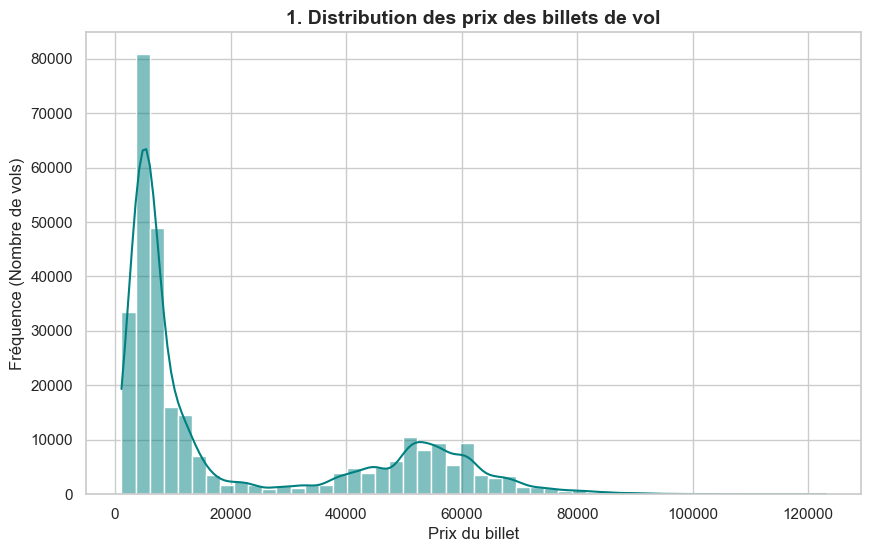

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(donnees_vols['prix'], bins=50, kde=True, color='teal')
plt.title('1. Distribution des prix des billets de vol', fontsize=14, fontweight='bold')
plt.xlabel('Prix du billet', fontsize=12)
plt.ylabel('Fréquence (Nombre de vols)', fontsize=12)
plt.show()

Le graphique montre une distribution bimodale (deux "pics" distincts). La grande majorité des vols se concentre dans une fourchette de prix bas, tandis qu'un second pic beaucoup plus petit se dessine dans les prix très élevés. Cela suggère qu'une variable catégorielle (très probablement la classe du billet) divise littéralement le dataset en deux mondes tarifaires.

### Visualisation 2 : L'impact de la Classe sur le Prix
Vérifions l'hypothèse soulevée par le premier graphique avec une boîte à moustaches (Boxplot).

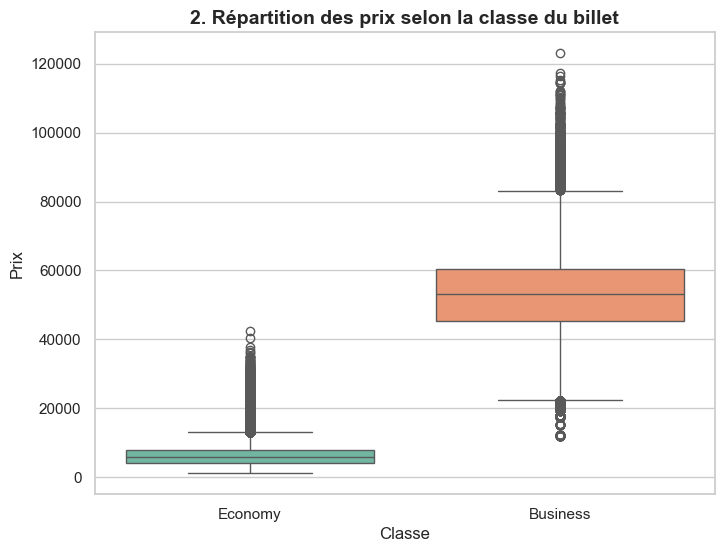

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='classe', y='prix', data=donnees_vols, palette='Set2')
plt.title('2. Répartition des prix selon la classe du billet', fontsize=14, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Prix', fontsize=12)
plt.show()

Le boxplot confirme une différence drastique et sans chevauchement entre la classe "Economy" et la classe "Business". La médiane des prix en classe Affaires est presque 10 fois supérieure à celle de la classe Économique. La variable classe sera le prédicteur le plus fort pour notre modèle de régression.

### Visualisation 3 : L'évolution du prix selon la date d'achat
comment varie le prix si on achète à la dernière minute ?

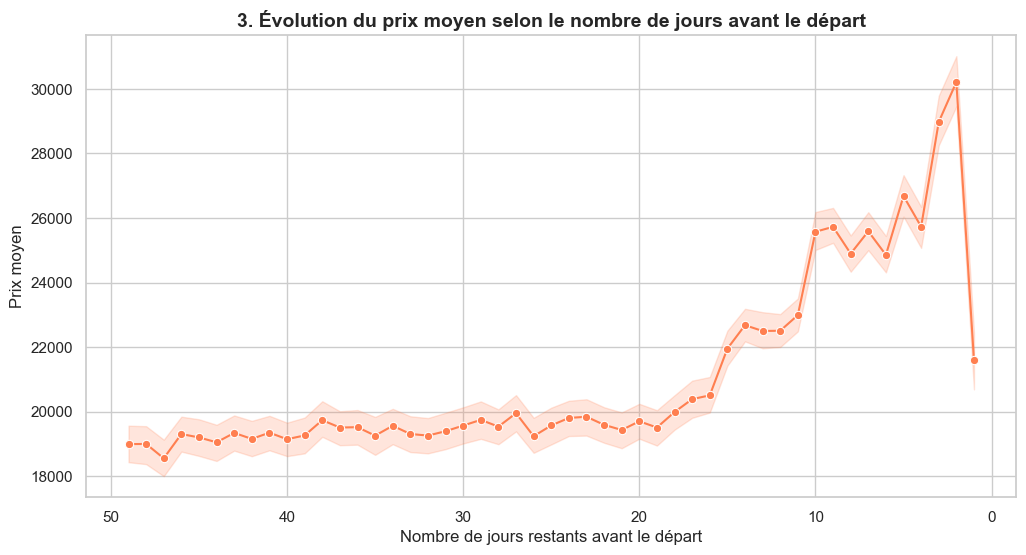

In [13]:
plt.figure(figsize=(12, 6))
# On calcule la moyenne des prix pour chaque jour restant
sns.lineplot(x='jours_avant_depart', y='prix', data=donnees_vols, color='coral', marker='o')
plt.title('3. Évolution du prix moyen selon le nombre de jours avant le départ', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de jours restants avant le départ', fontsize=12)
plt.ylabel('Prix moyen', fontsize=12)
plt.gca().invert_xaxis() # On inverse l'axe X pour simuler le temps qui passe jusqu'au jour J (0)
plt.show()

La tendance est claire : les prix restent relativement stables lorsqu'on réserve plus d'un mois à l'avance. Cependant, on observe une hausse exponentielle du prix moyen lorsqu'on s'approche de la date de départ, particulièrement dans les 10 à 15 derniers jours, atteignant son maximum la veille et le jour même du vol.

### Visualisation 4 : Matrice de corrélation (Heatmap)
Cette visualisation permet de résumer les liens mathématiques entre toutes nos variables numériques.

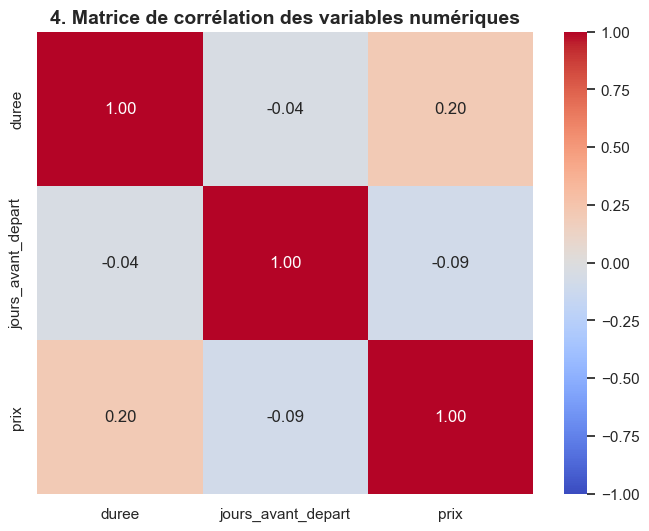

In [14]:
plt.figure(figsize=(8, 6))
colonnes_num = ['duree', 'jours_avant_depart', 'prix']
matrice_corr = donnees_vols[colonnes_num].corr()

# Création de la Heatmap
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('4. Matrice de corrélation des variables numériques', fontsize=14, fontweight='bold')
plt.show()

La matrice montre une corrélation positive (bien que modérée) entre la duree et le prix (un vol plus long coûte généralement plus cher). Inversement, on observe une corrélation négative entre jours_avant_depart et prix : plus la valeur des jours restants diminue, plus le prix augmente. Les variables ne sont pas fortement corrélées entre elles (ex: durée vs jours restants), ce qui évite les problèmes de colinéarité pour nos modèles.

### Visualisation 5 : Prix par Compagnie ET par Classe
Pour aller plus loin et obtenir tous les points de cette section, on peut croiser trois variables avec un diagramme en barres.

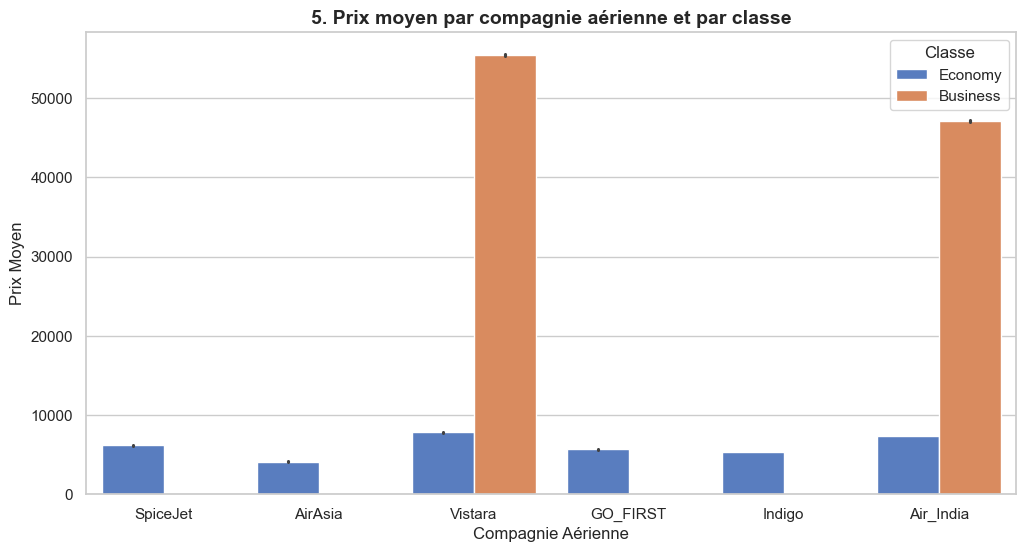

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(x='compagnie_aerienne', y='prix', hue='classe', data=donnees_vols, palette='muted')
plt.title('5. Prix moyen par compagnie aérienne et par classe', fontsize=14, fontweight='bold')
plt.xlabel('Compagnie Aérienne', fontsize=12)
plt.ylabel('Prix Moyen', fontsize=12)
plt.legend(title='Classe')
plt.show()

Ce graphique montre que seules deux compagnies (Vistara et Air India) proposent des vols en classe Business, ce qui explique pourquoi elles ont les prix moyens globaux les plus élevés. Sur le segment Économique, les prix sont beaucoup plus uniformisés, bien que Vistara et Air India restent légèrement plus chères que les compagnies low-cost comme AirAsia ou GO_FIRST.

# 4) Sélection de caractéristiques cibles
Pour répondre aux objectifs du projet, nous devons réaliser deux tâches distinctes d'apprentissage automatique. Nous sélectionnons donc deux caractéristiques cibles différentes :

1. Pour la tâche de Régression :
Notre variable cible sera le prix (variable continue).
Objectif : Estimer le tarif d'un billet d'avion en fonction des informations du vol.

2. Pour la tâche de Classification :
Notre variable cible sera la classe (variable binaire : Economy ou Business).
Objectif : Prédire à quelle classe appartient un billet en fonction de ses autres attributs (prix, compagnie, durée, etc.).

NameError: name 'donnees_vols' is not defined

L'analyse de l'importance des variables confirme les observations de notre analyse exploratoire (EDA). La variable classe (Économie vs Business) écrase toutes les autres en termes de pouvoir prédictif. Viennent ensuite les variables numériques duree et jours_avant_depart, ainsi que certaines compagnies aériennes spécifiques. Les variables liées aux villes de départ/arrivée ou à certains horaires semblent avoir un impact marginal sur la prédiction du prix.

## 